<a href="https://colab.research.google.com/github/0gerardo0/0gerardo0.github.io/blob/master/Taller23_alumni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

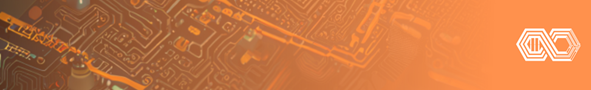
#**Clasificación de imágenes utilizando aprendizaje profundo (Deep Learning).**
##**Introducción a Google Colab.**
Instructor: Dr. Juan Manuel Fortuna Cervantes

Egresado del Posgrado en Ciencias Aplicadas, UASLP-Facultad de Ciencias-IICO

Email: juan.manuel.fortuna@hotmail.com & A158852@alumnos.uaslp.mx

**RESUMEN**

El objetivo principal del curso es dar una introducción a los conceptos básicos de la inteligencia artificial, así como conocer una de las principales técnicas del procesamiento digital de imágenes. El aprendizaje profundo es un subconjunto del aprendizaje máquina en el que las redes neuronales convolucionales (CNN por sus siglas en inglés) se adaptan y aprenden de grandes cantidades de datos. Se llevarán a cabo ejemplos prácticos mediante notebooks de Google Colab en Python para que los participantes puedan entender dichas técnicas y conceptos. Este tutorial está dirigido a personas que no tienen conocimiento sobre las CNNs.

**INFORMACIÓN DEL TALLER.**

Este es un taller teórico-práctico en el cual el instructor proporciona la teoría y la ejemplifica programando a la par con los participantes. En este taller los participantes aprenderán:
•	Conceptos básicos del aprendizaje profundo, tal es el caso de las CNNs.
•	A utilizar Google Colab (Tener una cuenta de email en gmail).
•	A formar y entrenar redes neuronales utilizando TensorFlow y Keras.
•	A desarrollar un clasificador de imágenes con la base de datos CIFAR-10.

**RECURSOS:**

**Requisitos:** Computadora con acceso a internet, sin características específicas.

**Libros de referencia:**
*   Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. Deep learning. MIT press, 2016. https://www.deeplearningbook.org/
*   Chollet, Francois. Deep learning with Python. Simon and Schuster, 2021.


**REFERENCIA: CIFAR-10 with CNN for beginer**

https://www.kaggle.com/code/roblexnana/cifar10-with-cnn-for-beginer/notebook

Table of interest:
1. Introduction
2. Import and Preprocess the data
* Import all required libraries
* Import and preproces of data
* Distribution of data.
3. Defining the model architecture Using ConVnets
4. Model training
5. Evaluate the model
* Training and validations cuvre
* Score trained model and prediction.
* Confusion matrix.
* Classification report.
* Check for the predictions.
6. Save model and weights


#**1. Introduction.**
**texto en negrita**The CIFAR-10 dataset contains 60,000 color images of 32 x 32 pixels in 3 channels divided into 10 classes. Each class contains 6,000 images. The training set contains 50,000 images, while the test sets provides 10,000 images. This image taken from the CIFAR repository ( https://www.cs.toronto.edu/~kriz/cifar.html ). This is a classification problem with 10 classes(muti-label classification). We can take a view on this image for more comprehension of the dataset.

![Cifar10](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)

The challenge is to recognize previously unseen images and assign them to one of the 10 classes.

Ok Let's get started.

#2. Import and Preprocess the data
##2.1 Import all required libraries


In [ ]:
#%tensorflow_version 1.x
import tensorflow.keras as keras
print('backend :', keras.backend.backend())
#print('keras version :', keras.__version__)

backend : tensorflow


AttributeError: ignored

In [ ]:
import numpy as np
import os
import cv2
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from time import time
import time
np.random.seed(2022)

In [ ]:
from keras.src import utils
from keras.utils import to_categorical
from keras.utils import plot_model
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, concatenate, AveragePooling2D, GlobalAveragePooling2D
from keras import optimizers, backend
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, CSVLogger, ReduceLROnPlateau
from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image as image_utils # Trabajar Imgs
#from keras.utils import np_utils
from keras import utils as np_utils #Trabajr imgs de tipo objeto a trabajar con ellas
from keras import backend as K
import tensorflow as tf
from tensorflow.keras.datasets import cifar10   # Función para descargar las imágenes de Cifar 10

In [ ]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 14303578588238565773
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14357954560
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8876989928368765171
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
!nvidia-smi

Fri Sep 15 18:49:15 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   45C    P0    28W /  70W |    359MiB / 15360MiB |      1%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

Let's setting the models hyperparameters and others global parameters.

In [ ]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 0.001# Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 10#100 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 32#, 64, 128 # cantidad de imágenes que se toman a la vez en memoria
img_width, img_height = 32, 32
data_augmentation = False
weight_decay = 0.0005


##2.2 Import and preproces of data¶

We load the data and split it between train and test sets


In [ ]:
# Obtención de las imágenes y sus etiquetas
# La función load_data() da como respuesta los grupos de entrenamiento y test por separado
### START CODE HERE ###
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
### END CODE HERE ###

170498071/170498071 [==============================] - 2s 0us/step


In [ ]:
# The data, split between train and test sets:
# Imprimimos el tamaño de los conjuntos de entrenamiento y prueba
print('El numero de imágenes en el conjunto x_train es:', x_train.shape[0])
### START CODE HERE ###
print('El numero de imágenes en el conjunto x_train es:', y_train.shape[0])
### END CODE HERE ###
print('El numero de imágenes en el conjunto x_test es:', x_test.shape[0])
### START CODE HERE ###
print('El numero de imágenes en el conjunto x_test es:', y_test.shape[0])
### END CODE HERE ###

El numero de imágenes en el conjunto x_train es: 50000
El numero de imágenes en el conjunto x_train es: 50000
El numero de imágenes en el conjunto x_test es: 10000
El numero de imágenes en el conjunto x_test es: 10000


In [ ]:
classes = np.unique(y_test)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]



##2.3 Distribution of data.

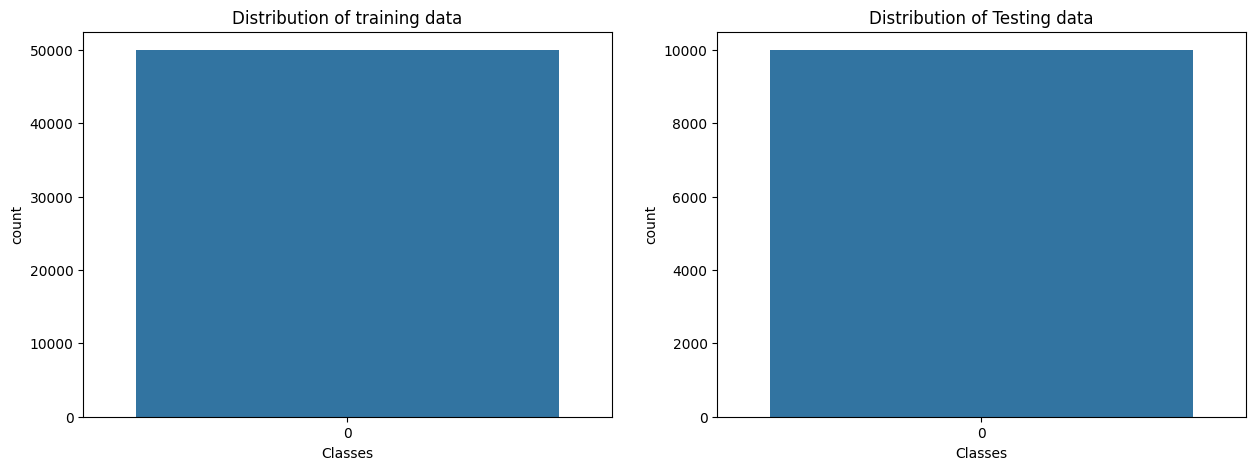

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))
# Count plot for training set
sns.countplot(y_train.ravel(), ax=axs[0])
axs[0].set_title('Distribution of training data')
axs[0].set_xlabel('Classes')
# Count plot for testing set
sns.countplot(y_test.ravel(), ax=axs[1])
axs[1].set_title('Distribution of Testing data')
axs[1].set_xlabel('Classes')
plt.show()

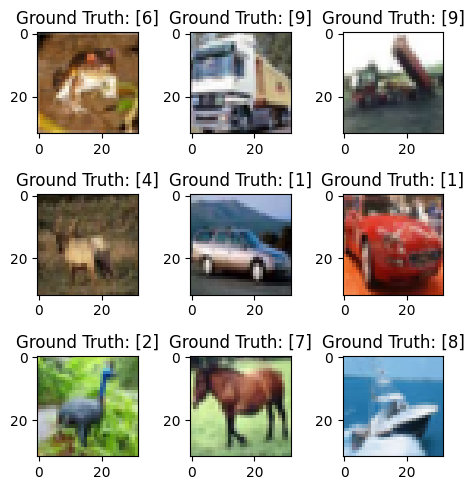

In [ ]:
for i in range(9):
    plt.figure(0, figsize=[5,5])
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='Accent') ### START CODE HERE ###

### END CODE HERE ###], cmap= 'Accent')
    plt.title("Ground Truth: {}".format(y_train[i]))
    plt.tight_layout()



As we can see, each classe contain exacly 6000 examples( 5000 for training and 1000 for test).

The graph above is very important for the training, for example if we had just 1000 samples of label 1 that will be a problem , the model will find difficulties to detect label 1"less accuracy ", so that's not going to happend everything look fine. It's important to know the distribution of dataset behind different classes because the goodness of our model depend on it.

Now let's doing some preprocessing.

The output variable have 10 posible values. This is a multiclass classification problem. We need to encode these lables to one hot vectors (ex : "bird" -> [0,0,1,0,0,0,0,0,0,0]).


Cuando se entrenan redes neuronales convolucionales no es necesario aplanar las imágenes en un vector, se usan con su formato matricial y numero de canales 3 (RGB).
Sin embargo, es recomendable escalar los valores de los pixeles de 0-255 a 0-1. También es necesario convertir a codificación 1-hot las etiquetas. Con 1-hot pasamos de tener una etiqueta que representa la clase 4 a un vector de 10 elementos donde el 4° elemento sea un 1 (comenzando desde la posición 0) etiqueta 4 -> 0000100000

In [ ]:
# Normalize the data. Before we need to connvert data type to float for computation.
# Con astype establecemos la precisión de los números a flotantes de 32 bits
x_train = x_train.astype('float32')
### START CODE HERE ###
x_test = x_test.astype('float32')
### END CODE HERE ###
# Escala los valores de los pixeles para que esten en el rango de 0 a 1
x_train /= 255
### START CODE HERE ###
x_test /= 255
### END CODE HERE ###

In [ ]:
x_train[0].shape

(32, 32, 3)

In [ ]:
# Convert class vectors to binary class matrices. This is called one hot encoding.
# Aplica codificación 1-hot de las etiquetas
### START CODE HERE ###
Y_train = np_utils.to_categorical(y_train)
### END CODE HERE ###
Y_test = np_utils.to_categorical(y_test)

# Visualiza la etiqueta 100 codificada
print(y_train[100], ' -> ', Y_train[100])

[8]  ->  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


### Reshape (volvemos al formato original)

Para poder entrenar redes convolucionales, los datos de imágenes deben tener un volumen:
$$ volumen = ancho \ (\text{número de filas}) \times alto \ (\text{número de columnas}) \times profundidad \ (\text{número de canales}). $$

Así, los datos deben representarse en forma de un tensor $d-$dimensional.
$$ input\_data = [ancho \ (\text{número de filas}), \ alto \ (\text{número de filas}), \ profundidad \ (\text{número de filas})]. $$

Las convnets (CNN) 2D asumen que los datos de entrada son una colección de imágenes, con tamaño número de renglones por número de columnas y varios canales (que codifican el color). Esto es, los datos deberán estar en formato de tensor de dimensión cuatro de la forma

$$ (\text{num datos} \times \text{num renglones} \times \text{num columnas} \times \text{num canales}). $$

Como las imágenes de CIFAR-10 son a color (tres canales - RGB) tenemos que agregar una dimensión extra al tensor de datos que corresponde al número de canales y debe ser igual a 3.


#3. Defining the model architecture Using ConVnets

Now Let us define a suitable deep net.

*   In the first stage, Our net will learn 32 convolutional filters, each of which with a 3 x 3 size. The output dimension is the same one of the input shape, so it will be 32 x 32 and activation is relu, which is a simple way of introducing non-linearity; folowed by another 32 convolutional filters, each of which with a 3 x 3 size and activation is also relu. After that we have a max-pooling operation with pool size 2 x 2 and a dropout at 25%.
*   In the next stage in the deep pipeline, Our net will learn 64 convolutional filters, each of which with a 3 x 3 size. The output dimension is the same one of the input shape and activation is relu; folowed by another 64 convolutional filters, each of which with a 3 x 3 size and activation is also relu. After that we have a max-pooling operation with pool size 2 x 2 and a dropout at 25%.
*   And the Final stage in the deep pipeline is a dense network with 512 units and relu activation followed by a dropout at 50% and by a softmax layer with 10 classes as output, one for each category.

Now let us look at the code review for our architecture.







### Etapa de extracción de características mediante una ConvNet

La red propuesta sigue siendo de tipo secuencial. Los datos se procesados por una capa alimentan a la capa siguiente hasta llegar a la capa de salida. Es decir, no hay retroalimentación o recurrencias: que la salida de capa se regrese a una capa previa.

El propósito de la red ConvNet es diseñar los filtros para que dados los parches de imagen de la entrada, reproducir la salida conocida.

La siguiente figura muestra la secuencia de dos etapas (bloques) y cada una corresponde a una subred secuencial.

### Capas convolucionales

El punto importante en aprendizaje profundo, es que aunque hayamos diseñado nuestra red considerando las distintas tareas que se realizarán (extracción de rasgos y clasificación), la red será entrenada en su totalidad. Luego, la división que hemos establecido en el diseño es una referencia, pero la frontera de las tareas será un tanto difusa.

En Keras, una capa convolucional 2D se llama mediante la instrucción _Conv2D_.

Los parámeros son

__filters:__ Dimensión del espacio de salida: número de filtros de convolución (serán no-lineales debido a la función de activación) que implementará la capa.

Para la primera capa, matemáticamente se escribe $x_2 = \varphi( H^{(i)} \otimes x_1)$, donde $x_1$ es la entradad a la primera capa (los datos), y $x_2$ es la salida (o entrada a la segunda capa). $H^{(i)}$ es el $i$-ésimo filtro de convolución y $\varphi(\cdot)$ es la función de activación (es tensorial y se aplica a cada elemento del tensor que resulta de $H^{(i)} \otimes x_1$).

__kernel_size:__ Dimensiones (renglones y columnas) de los filtros $H^{(i)}$. Si se da un solo valor, significa que son iguales en todas las dimensiones.

__stride:__ Entero o tupla de dos enteros con el paso de convolución en cada dimensión. Por default es 1 en cada dimensión.

__padding:__ {'valid', 'same'} Indica si el resultado tendrá los mismos (num_renglones, num_columnas) que el tensor de entrada o si la convolución solo se aplica sobre datos válidos (con efecto de reducción de bordes). Por default asume el 'valid'.

__data_format:__ {'channels_last', 'channels_first'} indica si los datos de estradad estan en formato (batch_size, image_height, image_width, image_channels) ó (batch_size, image_channels, image_height, image_width). Por default asume el primero.

__dilation_rate:__ Entero o tupla de dos enteros indicando la dilatación de la salida en cada dimensión.

__activation:__ Función de activación.

__use_bias:__ Booleana que indica si se usa vector de sesgo.

__kernel_initializer:__ Método de inicialización de los pesos de la matrix kernel.

__bias_initializer:__ Método de inicialización de los pesos del vector de sesgo.

__kernel_regularizer:__ Método de regularización de los pesos de la matriz kernel.

__bias_regularizer:__ Método de regularización de los pesos del vector de sesgo.

__kernel_constraint:__ Resticción sobre los pesos de la matriz kernel.

__bias_constraint:__ Resticción sobre los pesos del vector de sesgo.

Por ejemplo

    layers.Conv2D(filters=32, kernel_size=(3,3), stride=(1,1), padding='valid', activation='relu', name='name'))

puede escribirse como

    layers.Conv2D(32, kernel_size=(3,3), activation='relu', name='name'))
    
El tensor resultante de una capa de convolución será de (batch_size, image_height, image_width, image_channels=filters). Es decir cada filtro genera ahora una canal (respuesta del filtro

Se espera que:
* la información relevante en forma de relaciones espaciales en la imagen de entrada se codifique en forma de respuesta en algunos canales.
* pixeles vecinos tengas respuestas similares.
* respuestas altas se asocian con filtros entonados a detectar características relevantes.

### Pooling

Ahora, con la finalidad de resaltar la información relevante a la salida de la capa de convolución se aplica un proceso de pooling o agrupado. Esto se realiza mediante la capa _MaxPooling2D_

el formato es

    layers.MaxPooling2D(pool_size=(2,2), strides=None, padding='valid', name='name')
    
Los parámetros son

__pool_size:__ Entero o tupla indicando las dimensiones de la ventana sobre el que se seleccionará la máxima respuesta.

__strides:__ Entero o tupla indicando el paso (por default es igual a pool_size).

__padding:__ {'valid', 'same'} indica si el resultado tendrá los mismos (num_renglones, num_columnas) que el tensor de entrada o si la convolución solo se aplica sobre datos válidos (con efecto de reducción de bordes). Por default es 'valid'.

__data_format:__ {'channels_last' (default), 'channels_first'}.

Por ejemplo

    convNN.add(layers.MaxPooling2D(pool_size=(2,2), name='name'))

Un resultado inmediato de la capa de Pooling es la reducción de la dimensión de los datos. Esto permite que conforme se avanza en la red la información se concentra en un espacio de dimensión menor.

Los usual es añadir capas de Pooling entre las capas de convolución. Por ejemplo

    convNN.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    convNN.add(layers.MaxPooling2D(pool_size=(2, 2)))
    convNN.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))

La estrategia es ir transformando la información espacial en detección (respuesta) de filtros. Así, las dimensiones del tensor que se procesa se irán estrechando espacialmente a la vez que se añaden mas capas (filtros).

Las respuestas de la última capa se pueden entender como las características extraídas del vector de entrada.

La siguiente etapa es alimentar con las características extraídas una red multicapa para realizar la clasificación.

El primer paso es pasar el tensor de rasgos calculado por la etapa previa a un vector unidimensional. Esto lo hacemos con la capa _Flatten_, cuya definición esta dada por

    layers.Flatten(data_format=None, name='name')

que no requiere ningún parámetro.

Ahora agregamos una red con una arquitectura similar a la que usamos para clasificar los dígitos MNIST. La etapa se compone con varias capas Dense, y la de salida es un vector de dimesión 10. Sólo que ahora, en la primera capa oculta pondremos menos neuronas, pues los rasgos relevantes se han conservado y la información no relevante habre de haberse desechado.

## Dropout

Dropout es una técnica que sirve para regularizar el entrenamiento de una red neuronal. Fue introducida por Srivastava, Hinton, Krizhevsky, Sutskever y Salakhutdinov en 2014.

Se utiliza en la práctica para reducir el sobre-entrenamiento (overfitting) de la red, es decir, reducir la diferencia entre el error de entrenamiento y el error de validación/prueba.

La técnica consiste en que, durante cada batch, se eliminan un cierto porcentaje de neuronas, seleccionadas aleatoriamente, de la capa donde se aplica el Dropout. Esto permite que el entrenamiento no depende fuertemente de neuronas específicas, y que los pesos se distribuyen más adecuadamente dentro de las neuronas que sobreviven al drop-out.

Al entrenar el siguiente batch, la totalidad de neuronas se repobla completamente y se hace una nueva selección aleatoria de neuronas a eliminar.


El parámetro en una capa Dropout es:

__rate:__ Porcentaje ($0 \leq rate < 1$) de neuronas a eliminar aleatoriamente.

Así, si se quieren eliminar el 40% de las neuronas, en Keras se agrega la capa

    layers.Dropout(rate=0.4, name='name')

## Arquitectura LeNet-5
https://medium.com/@mgazar/lenet-5-in-9-lines-of-code-using-keras-ac99294c8086
![LeNet-5 Architecture. Credit: LeCun et al., 1998](https://miro.medium.com/max/1100/0*H9_eGAtkQXJXtkoK)
LeNet-5 Architecture. Credit: LeCun et al., 1998

In [ ]:
# Escribe la línea de código que elimina información previa de los modelos
backend.clear_session()

#Checking format of Image:
if K.image_data_format() == 'channels_first':
	input_shape = (3, img_width, img_height)
else:
	input_shape = (img_width, img_height, 3)

In [ ]:
from matplotlib.cbook import flatten
model = Sequential()
# Layer 1 Conv2D
model.add(Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), padding='valid', activation='relu', input_shape=input_shape))
# Layer 2 Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
# Layer 3 Conv2D
model.add(Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), padding='valid', activation='relu'))
# Layer 4 Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Flatten())
model.add(Dense(units=120, activation='relu'))
model.add(Dense(units=84, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         456       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 120)               4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#print(model.summary())
plot_model(model, to_file='cifar10_modelletnet5.pdf', show_shapes=True)

And now, let us train the model.

#4. Model training

Before making network ready for training we have to make sure to add below things:
*   A loss function: to measure how good the network is.
*   An optimizer: to update network as it sees more data and reduce loss value.
*   Metrics: to monitor performance of network.

Also note that for data augmentation:
*   One of the most commun tehnique to avoid overfitting is data augmentation. And We know that overfitting is generaly occur when we don't have enought data for training the model. To avoid this overfitting problem, we need to expand artificially our dataset. The idea is to alter the training data with small transformations to reproduce the variations occuring when someone is writing a digit.
*   Different data aumentation techniques are as follows: Cropping, Rotating, Scaling, Translating, Flipping, Adding Gaussian noise to input images, etc...





In [ ]:
# Definimos el optimizador Adam, que es una variante de Gradiente Descendente
Adam = tf.keras.optimizers.legacy.Adam(lr = INIT_LR, beta_1 = 0.9, beta_2 = 0.999,
                       epsilon = 1e-08, decay =0.0) # Los parámetros que proponemos para beta_1, beta_2, epsilon y decay
                                                    # han probado dar buenos resultados en la práctica
#sgd = optimizers.SGD(learning_rate=INIT_LR, decay=1e-06, momentum=0.9, nesterov=True)
#opt_rms = optimizers.rmsprop(lr=INIT_LR,decay=1e-6)

def lr_schedule(epoch):
    lrate = 0.001
    if epoch > 2:
        lrate = 0.001
    elif epoch > 80:
        lrate = 0.001
    return lrate

# Compilamos el modelo
model.compile (loss = 'categorical_crossentropy', optimizer=Adam, metrics = ['acc'])#accuracy para versiones recientes
###################################################################################################################
# Define un checkpointer para guardar los pesos sinapticos de la red
checkpointer = ModelCheckpoint('c101_modelletnet5.h5', monitor='val_loss', save_best_only=True, mode='min',verbose=1)
#Define EarlyStopping para monitorear variable, su efecto se activa al cumplir 20 epocas sin incremento.
early = EarlyStopping(monitor='val_acc', min_delta=0, patience=20, verbose=1, mode='max')
#Define CSVLogger para guardar las metricas en cada epoca
csv_logger = CSVLogger('c101_modelhistory.csv', append=True)
#Define ReduceLROnPlateau Reduce learning rate when a metric has stopped improving.
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=10,verbose=1,mode='min',cooldown=2, min_lr=1e-7)

NameError: ignored

In [ ]:
###################################################################################################################
if not data_augmentation:
    print('Not using data augmentation.')
    # Entrenamos el modelo: Aprende a clasificar imágenes.
    tic = time.time()
    M = model.fit(x_train, Y_train, epochs=epochs, validation_split=0.15, verbose=2, shuffle=True, batch_size=batch_size, callbacks=[checkpointer,early,LearningRateScheduler(lr_schedule), csv_logger, reduce_lr])
    print('Total training time:', time.time()-tic, 'seconds')
else:
    print('Using real-time data augmentation.')
    # This will do preprocessing and realtime data augmentation:
    datagen = ImageDataGenerator(featurewise_center=False,samplewise_center=False,
                                 featurewise_std_normalization=False,  # divide inputs by std of the dataset
                                 samplewise_std_normalization=False,  # divide each input by its std
                                 zca_whitening=False,  # apply ZCA whitening
                                 zca_epsilon=1e-06,  # epsilon for ZCA whitening
                                 rotation_range=0,  # randomly rotate images in the range (degrees, 0 to 180)
                                 # randomly shift images horizontally (fraction of total width)
                                 width_shift_range=0.1, # randomly shift images vertically (fraction of total height)
                                 height_shift_range=0.1,
                                 shear_range=0.,  # set range for random shear
                                 zoom_range=0.,  # set range for random zoom
                                 channel_shift_range=0.,  # set range for random channel shifts
                                 # set mode for filling points outside the input boundaries
                                 fill_mode='nearest',
                                 cval=0.,  # value used for fill_mode = "constant"
                                 horizontal_flip=True,  # randomly flip images
                                 vertical_flip=False,  # randomly flip images
                                 # set rescaling factor (applied before any other transformation)
                                 rescale=None,
                                 # set function that will be applied on each input
                                 preprocessing_function=None,
                                 # image data format, either "channels_first" or "channels_last"
                                 data_format=None)
                                 # fraction of images reserved for validation (strictly between 0 and 1)
                                 #validation_split=0.0)
                                 # Compute quantities required for feature-wise normalization
# (std, mean, and principal components if ZCA whitening is applied).
    datagen.fit(train_x)
	# Fit the model on the batches generated by datagen.flow().
     #validation_data=(valid_X, valid_label)
    # Entrenamos el modelo: Aprende a clasificar imágenes.
    tic = time.time()
    M = model.fit_generator(datagen.flow(train_x, train_label,batch_size=batch_size))#,
                            #validation_data=(valid_x, valid_label),
                            #steps_per_epoch=len(train_x)//batch_size, epochs=epochs, verbose=2, shuffle=True,
                            #callbacks=[checkpointer,early,LearningRateScheduler(lr_schedule), csv_logger, reduce_lr])
    print('Total training time:', time.time()-tic, 'seconds')

Not using data augmentation.
Epoch 1/10

Epoch 1: val_loss improved from inf to 1.46697, saving model to c101_modelletnet5.h5
1329/1329 - 17s - loss: 1.6306 - acc: 0.4036 - val_loss: 1.4670 - val_acc: 0.4679 - lr: 0.0010 - 17s/epoch - 13ms/step
Epoch 2/10


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 1.46697 to 1.31314, saving model to c101_modelletnet5.h5
1329/1329 - 6s - loss: 1.3741 - acc: 0.5072 - val_loss: 1.3131 - val_acc: 0.5304 - lr: 0.0010 - 6s/epoch - 4ms/step
Epoch 3/10

Epoch 3: val_loss improved from 1.31314 to 1.30014, saving model to c101_modelletnet5.h5
1329/1329 - 5s - loss: 1.2791 - acc: 0.5429 - val_loss: 1.3001 - val_acc: 0.5375 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 4/10

Epoch 4: val_loss improved from 1.30014 to 1.26223, saving model to c101_modelletnet5.h5
1329/1329 - 6s - loss: 1.2035 - acc: 0.5721 - val_loss: 1.2622 - val_acc: 0.5572 - lr: 0.0010 - 6s/epoch - 4ms/step
Epoch 5/10

Epoch 5: val_loss improved from 1.26223 to 1.22684, saving model to c101_modelletnet5.h5
1329/1329 - 5s - loss: 1.1467 - acc: 0.5920 - val_loss: 1.2268 - val_acc: 0.5733 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 6/10

Epoch 6: val_loss improved from 1.22684 to 1.17941, saving model to c101_modelletnet5.h5
1329/1329 - 6s - loss: 1.0962 - acc: 0.611


#5. Evaluate the model.
##5.1 Training and validation curves.

Let's see the training and validation process by the visualization of history of fitting. This allow us to quickly know if how our model fit our data (overfitting, underfitting, model convergence, etc...)


In [ ]:
accuracy = M.history['acc']
val_accuracy = M.history['val_acc']
loss = M.history['loss']
val_loss = M.history['val_loss']
epochs = range(1, len(accuracy) + 1)

plt.figure(1)
plt.plot(epochs, accuracy, '-b', label='Training acc')
plt.plot(epochs, val_accuracy, '-c', label='Validation acc')
plt.title('Training and validation accuracy')
plt.suptitle("CIFAR10", fontsize=10)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right') #'best'
plt.hlines(y=0.5315, xmin=0, xmax=10, colors='k', linestyles='dashed')
plt.savefig('c101_img2.pdf')

In [ ]:
plt.figure(2)
plt.plot(epochs, loss, '--y', label='Training loss')
plt.plot(epochs, val_loss, '--g', label='Validation loss')
plt.title('Training and validation loss')
plt.suptitle("CIFAR10", fontsize=10)
plt.xlabel('Epochs')
plt.ylabel('Loss (%)')
plt.legend(loc='best')
plt.hlines(y=1.2942, xmin=0, xmax=10, colors='k', linestyles='dashed')
#plt.show()
plt.savefig('c101_img3.pdf')

In [ ]:
plt.figure(3)
plt.plot(epochs, accuracy, '-b', label='Training acc')
plt.plot(epochs, val_accuracy, '-c', label='Validation acc')
plt.plot(epochs, loss, '--y', label='Training loss')
plt.plot(epochs, val_loss, '--g', label='Validation loss')
plt.title('Training and validation accu & loss',fontsize=16, fontweight='bold')
plt.suptitle("CIFAR10", fontsize=10)
plt.xlabel('Epochs')
plt.ylabel('Accuracy(%) - Loss (%)')
plt.legend(loc='best')
#plt.show()
plt.savefig('c101_img4.pdf')

##5.2 Score trained model and prediction.

In [ ]:
# Score trained model.
model = tf.keras.models.load_model("c101_modelletnet5.h5")
test_eval = model.evaluate(x_test, Y_test, verbose=2)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

# make prediction.
pred = model.predict(x_test)



Now Let's investigate for errors.

#5.3 Confusion matrix.

Confusion matrix can be very helpfull to see your model drawbacks. We plot the confusion matrix of the validation results. For good vizualization of our confusion matrix, we have to define to fonction.

In [ ]:
def heatmap(data, row_labels, col_labels, ax=None, cbar_kw={}, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.
    """
    if not ax:
        ax = plt.gca()

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)
    # We want to show all ticks...
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    # ... and label them with the respective list entries.
    ax.set_xticklabels(col_labels, rotation=45)
    ax.set_yticklabels(row_labels)

    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return im, cbar

def annotate_heatmap(im, data=None, fmt="d", threshold=None):
    """
    A function to annotate a heatmap.
    """
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            text = im.axes.text(j, i, format(data[i, j], fmt), horizontalalignment="center",
                                 color="white" if data[i, j] > thresh else "black")
            texts.append(text)

    return texts

In [ ]:
labels = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(pred, axis=1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y_test, axis=1)
# Errors are difference between predicted labels and true labels
errors = (Y_pred_classes - Y_true != 0)

Y_pred_classes_errors = Y_pred_classes[errors]
Y_pred_errors = pred[errors]
Y_true_errors = Y_true[errors]
X_test_errors = x_test[errors]

cm = confusion_matrix(Y_true, Y_pred_classes)
thresh = cm.max() / 2.

fig, ax = plt.subplots(figsize=(8,8))
im, cbar = heatmap(cm, labels, labels, ax=ax,
                   cmap=plt.cm.Blues, cbarlabel="count of predictions")
texts = annotate_heatmap(im, data=cm, threshold=thresh)

fig.tight_layout()
#plt.show()
plt.savefig('c101_img5.pdf')


#5.5 Check the predictions.

In [ ]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, R*C):
    axes[i].imshow(x_test[i])
    axes[i].set_title("True: %s \nPredict: %s" % (labels[Y_true[i]], labels[Y_pred_classes[i]]))
    axes[i].axis('off')
    plt.subplots_adjust(wspace=1)

 Check the wrong predictions.

In [ ]:
R = 3
C = 5
fig, axes = plt.subplots(R, C, figsize=(12,8))
axes = axes.ravel()

misclassified_idx = np.where(Y_pred_classes != Y_true)[0]
for i in np.arange(0, R*C):
    axes[i].imshow(x_test[misclassified_idx[i]])
    axes[i].set_title("True: %s \nPredicted: %s" % (labels[Y_true[misclassified_idx[i]]],
                                                  labels[Y_pred_classes[misclassified_idx[i]]]))
    axes[i].axis('off')
    plt.subplots_adjust(wspace=1)

Check the most important errors.

In [ ]:
def display_errors(errors_index, img_errors, pred_errors, obs_errors):
    """ This function shows 10 images with their predicted and real labels"""
    n = 0
    nrows = 2
    ncols = 5
    fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True, figsize=(12,6))
    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row,col].imshow((img_errors[error]).reshape((32,32,3)))
            ax[row,col].set_title("Predicted:{}\nTrue:{}".
                                  format(labels[pred_errors[error]],labels[obs_errors[error]]))
            n += 1
            ax[row,col].axis('off')
            plt.subplots_adjust(wspace=1)

# Probabilities of the wrong predicted numbers
Y_pred_errors_prob = np.max(Y_pred_errors,axis = 1)

# Predicted probabilities of the true values in the error set
true_prob_errors = np.diagonal(np.take(Y_pred_errors, Y_true_errors, axis=1))

# Difference between the probability of the predicted label and the true label
delta_pred_true_errors = Y_pred_errors_prob - true_prob_errors

# Sorted list of the delta prob errors
sorted_dela_errors = np.argsort(delta_pred_true_errors)

# Top 10 errors
most_important_errors = sorted_dela_errors[-10:]

# Show the top 10 errors
display_errors(most_important_errors, X_test_errors, Y_pred_classes_errors, Y_true_errors)

## Aprendamos de los errores. (EXTRA)

In [ ]:
clases=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
#predicted_classes2 = model.predict([x_test, x_testA])
predicted_classes=[]
for predicted_imgs in pred: #predicted_classes2:
    predicted_classes.append(predicted_imgs.tolist().index(max(predicted_imgs)))
predicted_classes=np.array(predicted_classes)
predicted_classes.shape, y_test.shape# se refiere a la variable de etiquetas antes del 1-hot

((10000,), (10000, 1))

In [ ]:
y_test = y_test.reshape(10000,)
y_test.shape

(10000,)

In [ ]:
correct = np.where(predicted_classes==y_test)[0]
print("Found %d correct labels" % len(correct))

incorrect = np.where(predicted_classes!=y_test)[0]
print("Found %d incorrect labels" % len(incorrect))

Found 5306 correct labels
Found 4694 incorrect labels


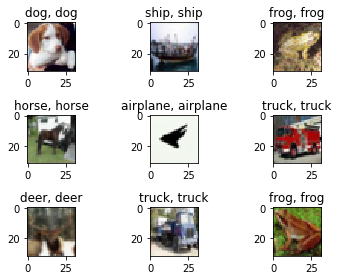

In [ ]:
for i, correct in enumerate(correct[10:19]):
    plt.figure(4)
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[correct].reshape(32, 32, 3), cmap= 'Accent', interpolation='none')
    plt.title("{}, {}".format(clases[predicted_classes[correct]], clases[y_test[correct]]))
    plt.tight_layout()
    #plt.show()
    plt.savefig('c101_img6.pdf')

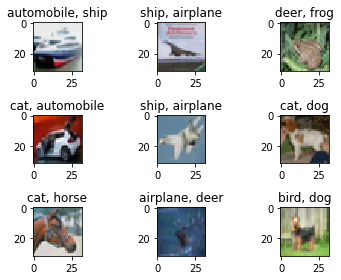

In [ ]:
for i, incorrect in enumerate(incorrect[0:9]):
    plt.figure(5)
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[incorrect].reshape(32, 32, 3), cmap= 'Accent', interpolation='none')
    plt.title("{}, {}".format(clases[predicted_classes[incorrect]], clases[y_test[incorrect]]))
    plt.tight_layout()
    #plt.show()
    plt.savefig('c101_img7.pdf')


#5.4 Classification report

This will allow us to evaluate the model with other metrics (Precision, Recall, F1 score, etc...)


In [ ]:
print(classification_report(y_test, predicted_classes, target_names=clases))

##Testing the model with the test images in the test set.

Now we can play with our model for some fun.

In [ ]:
def show_test(number):
    fig = plt.figure(figsize = (3,3))
    test_image = np.expand_dims(x_test[number], axis=0)
    test_result = model.predict(test_image)
    plt.imshow(x_test[number])
    dict_key = test_result[0]
    plt.title("Predicted: {} \nTrue Label: {}".format(labels[dict_key],
                                                      labels[Y_true[number]]))

1/1 [==============================] - 0s 17ms/step


TypeError: ignored

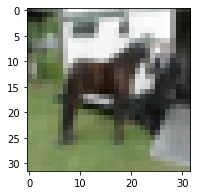

In [ ]:
show_test(20)

1/1 [==============================] - 0s 170ms/step


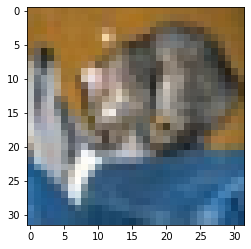

La imagen 0, tiene la etiqueta 3, el modelo lo clasifica como: [[0.00426423 0.00099237 0.03822434 0.5512297  0.01202377 0.33165357
  0.02961138 0.02315029 0.00525073 0.00359953]]


In [ ]:
# EJERCICIO
# Prueba del modelo
n_imagen = 0
imagen = x_test[n_imagen]
etiqueta = y_test[n_imagen]
prediccion = model.predict(imagen.reshape(1,32,32,3))

# Gráfica de la imagen
plt.imshow(imagen)
plt.show()
print('La imagen {}, tiene la etiqueta {}, el modelo lo clasifica como: {}'.format(n_imagen, etiqueta, prediccion))


#6. Save model and weights¶

Note that we need to firstly indicate the directory to save the model and the name of our model.


In [ ]:
save_dir = os.path.join(os.getcwd(), 'saved_models')
model_name = 'keras_cifar10_trained_model.h5'

# Save model and weights
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print('Saved trained model at %s ' % model_path)

# Score trained model.
#scores = model.evaluate(x_test, y_test, verbose=1)
#print('Test loss:', scores[0])
#print('Test accuracy:', scores[1])

Saved trained model at /content/saved_models/keras_cifar10_trained_model.h5 
